In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [7]:
# Constante gravitacional
g = 9.81

# Sistema de ecuaciones
def Sistema(r, t):
    x, v = r
    dxdt = v
    dvdt = - (4 * x * v**2 + 2 * x * g) / (4 * x**2 + 1)
    return [dxdt, dvdt]


# Tiempo de integración
t = np.linspace(0, 5, 50)
# Condiciones iniciales
x0, v0 = 0.2, 0.
y0 = np.array([x0, v0])
# Integrador
sol = odeint(Sistema, y0, t)
x_sol = sol[:, 0]
v_sol = sol[:, 1]
#plt.plot(t,x_sol)

In [8]:
# Animation
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(131)
ax1 = fig.add_subplot(132)
ax2 = fig.add_subplot(133)

def init():
  ax.set_xlim(t[0], t[-1])
  ax.set_ylim(min(x_sol)*1.1, max(x_sol)*1.1)
  ax.set_xlabel('t')
  ax.set_ylabel('x(t)')
  ax.set_title('Posición')

  scale = 4
  ax1.set_xlim(scale*min(x_sol), scale*max(x_sol))
  ax1.set_ylim(0,scale*max(x_sol**2))
  ax1.set_xlabel('x(t)')
  ax1.set_ylabel('y(t)')
  ax1.set_title('Trayectoria')

  scale = 1.2
  ax2.set_xlim(scale*min(x_sol), scale*max(x_sol))
  ax2.set_ylim(scale*min(v_sol), scale*max(v_sol))
  ax2.set_xlabel('x(t)')
  ax2.set_ylabel('v(t)')
  ax2.set_title('Espacio de fase')

def Update(i):
  ax.clear()
  ax1.clear()
  ax2.clear()
  init()
  ax.plot(t[:i], x_sol[:i],'b')

  _x = np.linspace(-2*x0,2*x0,100)
  ax1.plot(_x,_x**2,color='k')

  ax1.scatter(x_sol[i], x_sol[i]**2,color='r')

  ax2.plot(x_sol[:i], v_sol[:i],'k')
  return []

# Crear animación
ani = FuncAnimation(fig, Update, frames=len(t), init_func=init)

# Mostrar en Colab
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [9]:
# Guardar como video
#ani.save("RestriccionNewton.mp4", writer="ffmpeg", fps=10)
# Descargarlo
from google.colab import files
#files.download("RestriccionNewton.mp4")

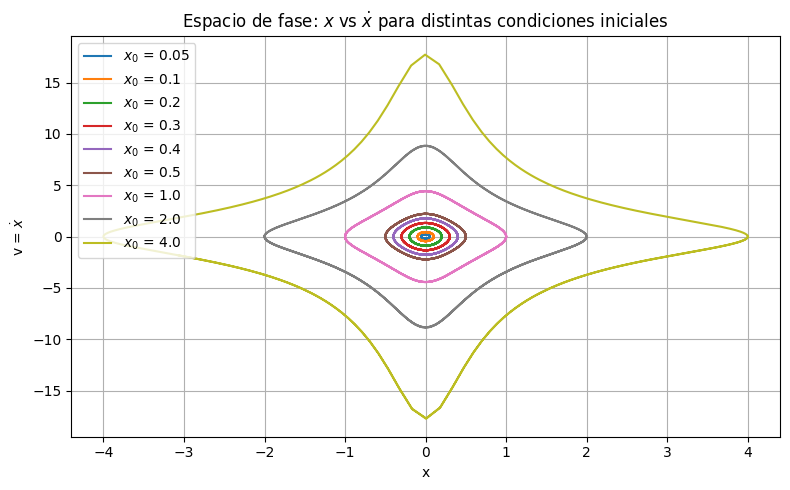

In [10]:
plt.figure(figsize=(8, 5))

condiciones_iniciales = [
    [0.05, 0.0],
    [0.1, 0.0],
    [0.2, 0.0],
    [0.3, 0.0],
    [0.4, 0.0],
    [0.5, 0.0],
    [1.0, 0.0],
    [2.0, 0.0],
    [4.0, 0.0]
]

t = np.linspace(0, 10, 1000)

for y0 in condiciones_iniciales:
    sol = odeint(Sistema, y0, t)
    x_sol = sol[:, 0]
    v_sol = sol[:, 1]
    plt.plot(x_sol, v_sol, label=f'$x_0$ = {y0[0]}')

# Estética del gráfico
plt.title("Espacio de fase: $x$ vs $\\dot{x}$ para distintas condiciones iniciales")
plt.xlabel("x")
plt.ylabel("v = $\dot{x}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()